In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
n_trials = 10
x = np.arange(0, n_trials)

mu_hr, sigma_hr = 70.0, 10.0
mu_bel, sigma_bel = 60.0, 5.0
alpha, beta = -10.0, 5.0
heart_rates = np.random.normal(mu_hr, sigma_hr, n_trials)
tones_bpm = np.arange(10, 200)
tones_bias = np.arange(-40, 40)
listening_tones = np.linspace(20, 150, n_trials)
deciding_tones = np.linspace(20, 150, n_trials)

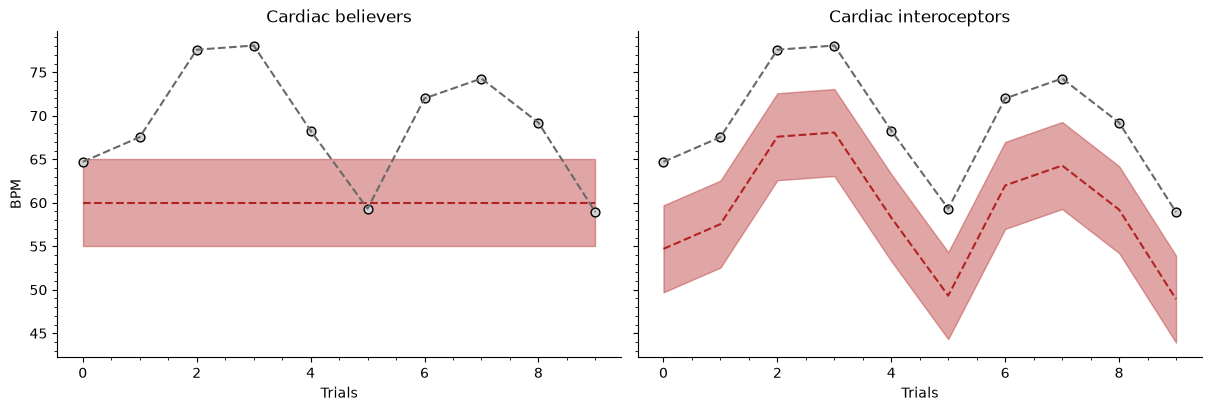

In [3]:
_, axs = plt.subplots(figsize=(12, 4), ncols=2, sharey=True)

axs[0].fill_between(
    x=x,
    y1=mu_bel - sigma_bel,
    y2=mu_bel + sigma_bel,
    color="firebrick",
    alpha=0.4,
)
axs[0].plot(
    x,
    np.ones(n_trials) * mu_bel,
    linestyle="--",
    color="firebrick",
)

axs[0].plot(
    x,
    heart_rates,
    linestyle="--",
    color="dimgray",
)

axs[0].scatter(
    x,
    heart_rates,
    s=40,
    color="lightgrey",
    edgecolor="k",
)

axs[1].fill_between(
    x=x,
    y1=heart_rates + alpha - beta,
    y2=heart_rates + alpha + beta,
    color="firebrick",
    alpha=0.4,
)
axs[1].plot(
    x,
    np.ones(n_trials) * heart_rates + alpha,
    linestyle="--",
    color="firebrick",
)

axs[1].plot(
    x,
    heart_rates,
    linestyle="--",
    color="dimgray",
)

axs[1].scatter(
    x,
    heart_rates,
    s=40,
    color="lightgrey",
    edgecolor="k",
)

axs[0].set(title="Cardiac believers", ylabel="BPM")
axs[1].set(title="Cardiac interoceptors")
axs[0].minorticks_on()
axs[1].minorticks_on()

axs[0].set(xlabel="Trials")
axs[1].set(xlabel="Trials")
sns.despine()
# plt.savefig(Path().cwd().parent.parent / "figures" / "fig_4_hgf_precision.svg")

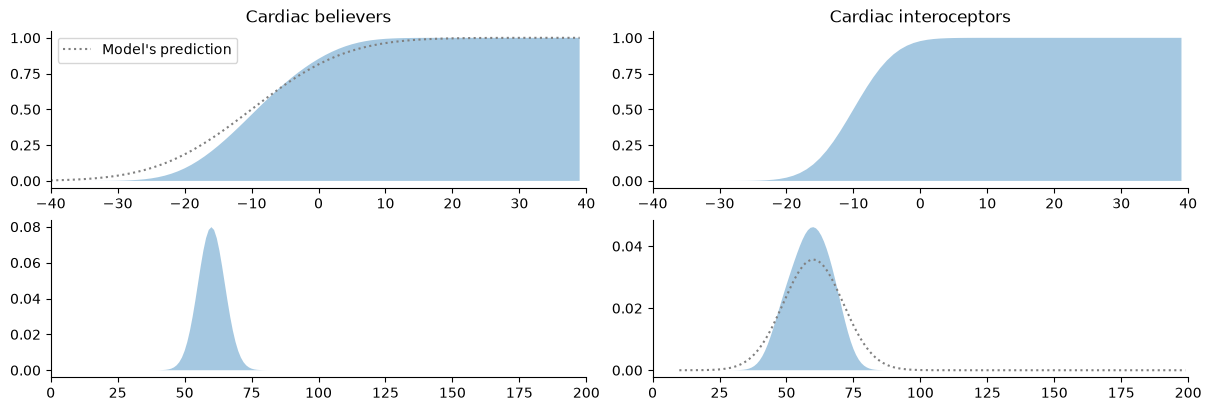

In [4]:
_, axs = plt.subplots(figsize=(12, 4), nrows=2, ncols=2)

# cardiac believers ---

# psychometric function
axs[0, 0].fill_between(
    tones_bias,
    np.array([norm.cdf(tones_bias, mu_bel - hr, sigma_bel) for hr in heart_rates]).mean(
        0
    ),
    alpha=0.4,
)
axs[0, 0].plot(
    tones_bias,
    norm.cdf(tones_bias, mu_bel - mu_hr, np.sqrt(sigma_bel**2 + sigma_hr**2)),
    label=r"Model's prediction",
    color="grey",
    linestyle=":",
)
axs[0, 0].set(xlim=(-40, 40), title="Cardiac believers")
axs[0, 0].legend()
# cardiac belief
axs[1, 0].fill_between(
    tones_bpm,
    np.array([norm.pdf(tones_bpm, mu_bel, sigma_bel) for _ in heart_rates]).mean(0),
    alpha=0.4,
)
axs[1, 0].set(xlim=(0, 200))

# cardiac interoceptors ---

# psychometric function
axs[0, 1].fill_between(
    tones_bias,
    np.array([norm.cdf(tones_bias, alpha, beta) for _ in heart_rates]).mean(0),
    alpha=0.4,
)
axs[0, 1].set(xlim=(-40, 40), title="Cardiac interoceptors")

# cardiac belief
axs[1, 1].fill_between(
    tones_bpm,
    np.array([norm.pdf(tones_bpm, hr + alpha, beta) for hr in heart_rates]).mean(0),
    alpha=0.4,
)
axs[1, 1].plot(
    tones_bpm,
    norm.pdf(tones_bpm, mu_hr + alpha, np.sqrt(beta**2 + sigma_hr**2)),
    label=r"Model's prediction",
    color="grey",
    linestyle=":",
)
axs[1, 1].set(xlim=(0, 200))

sns.despine()